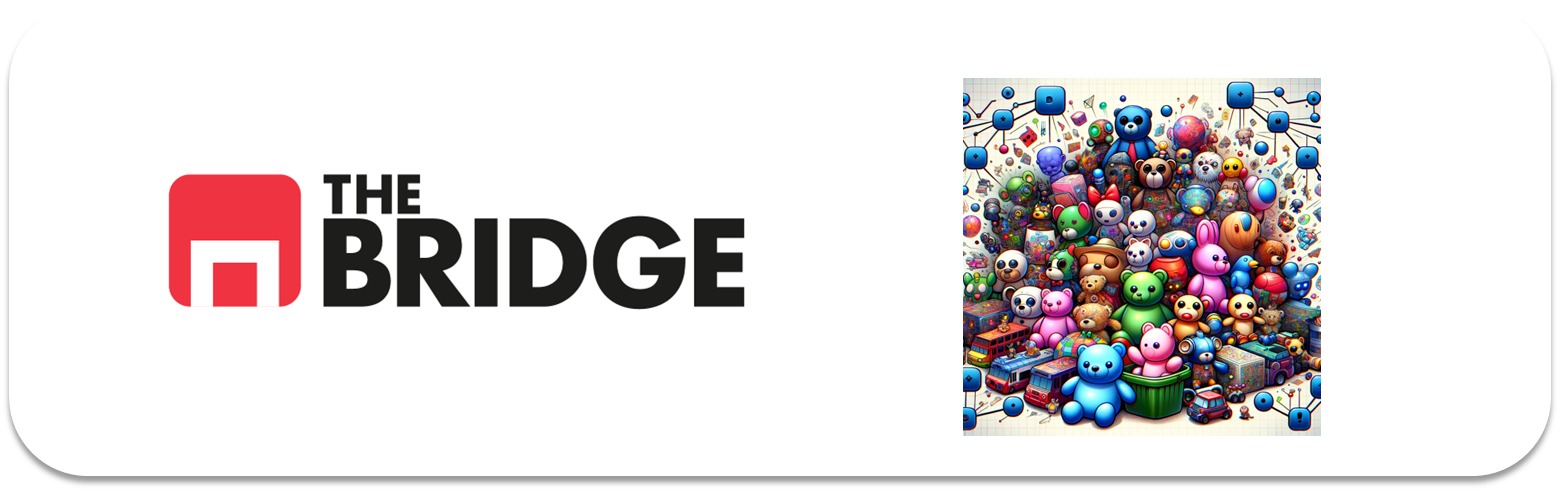

## PRACTICA OBLIGATORIA: **DBSCAN y Clustering Jerárquico**

* La práctica obligatoria de esta unidad consiste en un ejercicio de modelado no supervisado aplicado a clustering jerárquico y no jerárquico. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Parte I. Modelado

#### Descripción del problema.

En una planta de experimentación con nuevas bebidas energéticas están trabajando con diferentes mezclas de componentes para obtener posibles variedades de su producto estrella "NonstopU". El problema es que la fabricación de cada "prototipo" conlleva demasiado tiempo y las pruebas de sabores y de propiedades "non-stop" antisueño y antifatiga son costosas.  

En ese sentido quieren construir algún sistema de segmentación previa de mezclas sin probarlas solo indicando las cantidades de cada componente de la bebida. Tienen datos pero desgraciadamente de mezclas anteriores con diferentes medidas pero que por temas presupuestarios y de prioridad no se hicieron test con usuarios y potenciales clientes, es decir no tienen un target de capacidad antifatiga o de preferncia del usuario que puedas servirles para construir un clasificador clásico como han hecho otras veces.  

Han acudido a vosotros con la necesida de encontrar ese segmentador de posibles bebidas y con los datos de las mezclas no probadas anteriores por ver si vostros podéis ayudarles a encontrar algún tipo de segmentación que luego ello se encargarían de interpretar. No es requisito obligatorio pero les gustaría también poder establecer algún tipo de relación entre las segmentaciones (tipo cuales segmentos se "parecerían" más entre sí)

NOTA ORIENTATIVA: Los químicos no esperan que haya menos de 3 segmentos ni más de 5.  
NOTA OPERATIVA: El dataset con los datos que nos han dado los químicos está en "./data/empowering_drinks.csv"

**Se pide**: Construir al menos dos algoritmos de clustering (DBSCAN debe ser uno de ellos y el otro debería estar claro cual deberíamos usar dado el enunciado). Compararlos brevemente aunque sea meramente especulativo (¿Por qué es espculativo?)

**Se recomienda**: Visualizar las features dos a dos para escoger las mejores, no necesariamente hay que usar todas, ni tampoco quedarse en dos. Probar diferentes hiperparámetros en función de la nota orientativa y explicar porqué se han escogido los que finalmente se hayan escogido. 

Recuerda que el proceso es similar a lo que vimos en el otro tipo de aprendizaje:
1. Entender el problema
2. Cargar datos, visualizar.
3. MiniEDA: Selección de features
4. Tratamiento de Features.
5. Selección de modelos, selección de hiperparámetros
6. Entrenamiento, visualización de resultados.
7. Discusión de los mismos


In [3]:
df = pd.read_csv('./data/empowering_drinks.csv', sep='|')

print(df.shape)
df.head()

(153, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.518613,0.232053,1.034819,1.013009,0.251717
1,0.246290,-0.827996,0.733629,0.965242,-0.293321
2,0.196879,1.109334,1.215533,1.395148,0.269020
3,1.691550,0.487926,1.466525,2.334574,1.186068
4,0.295700,1.840403,0.663351,-0.037874,-0.319276


In [4]:
print(df.isnull().sum())

Azúcares                 0
Vitamínas del grupo B    0
Cafeína                  0
Ácido Cítrico            0
Taurina                  0
dtype: int64


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 153 entries, 0 to 152
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Azúcares               153 non-null    float64
 1   Vitamínas del grupo B  153 non-null    float64
 2   Cafeína                153 non-null    float64
 3   Ácido Cítrico          153 non-null    float64
 4   Taurina                153 non-null    float64
dtypes: float64(5)
memory usage: 6.1 KB


Vemos que todos los datos son válidos.

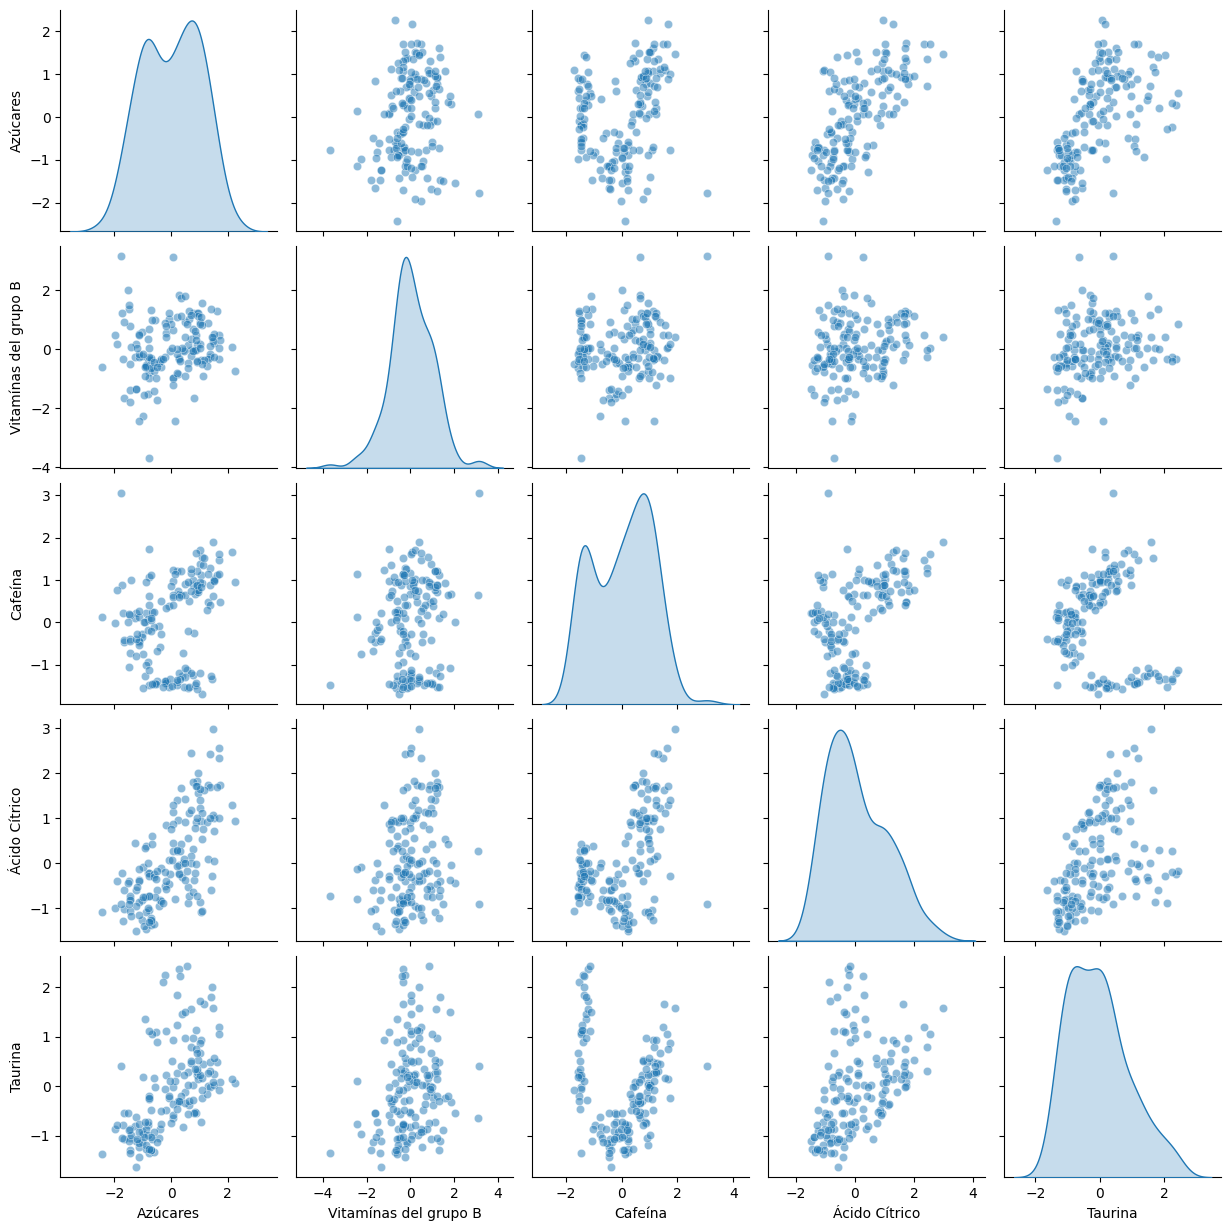

In [6]:
# Pairplot para ver relaciones entre todas las variables numéricas
sns.pairplot(df, diag_kind='kde', plot_kws={'alpha': 0.5})
plt.show()

Vemos que  taurina-cafeína es la pareja que mejor separan los datos en potenciales clústeres bien definidos. Pasamos a escalar los datos para poderlos usar en DBSCAN y NMeans.

In [11]:
from sklearn.preprocessing import StandardScaler

features_seleccionadas = ['Cafeína', 'Taurina'] 
X = df[features_seleccionadas]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features_seleccionadas)

X_scaled.describe()

,Cafeína,Taurina
count,1.530000e+02,1.530000e+02
mean,4.644070e-17,-1.161018e-17
std,1.003284e+00,1.003284e+00
min,-1.674210e+00,-1.707432e+00
25%,-1.045232e+00,-8.110253e-01
50%,1.643428e-01,-1.189805e-01
75%,8.223513e-01,5.777089e-01
max,2.912496e+00,2.658488e+00


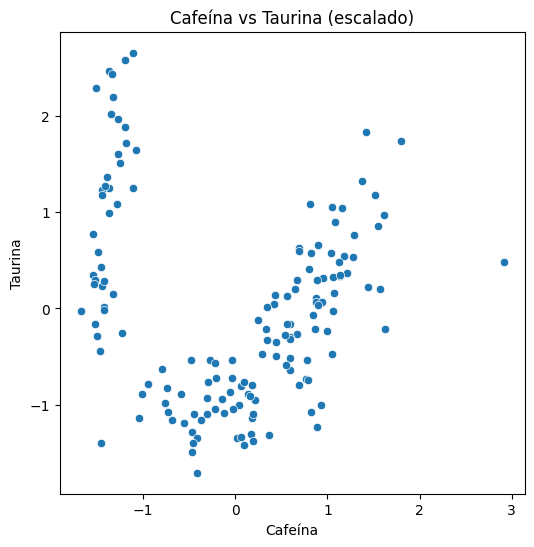

In [12]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=X_scaled, x='Cafeína', y='Taurina')
plt.title('Cafeína vs Taurina (escalado)')
plt.show()

Empecemos aplicando KMeans con los rangos sugeridos.

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados_kmeans = {}

for k in range(3, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    resultados_kmeans[k] = {'modelo': kmeans, 'labels': labels, 'silhouette': score}
    print(f"k={k}: silhouette_score={score:.4f}")

k=3: silhouette_score=0.5097
k=4: silhouette_score=0.5128
k=5: silhouette_score=0.4813


Como hay poca diferencia entre 3 y 4, vamos a visualizarlos:

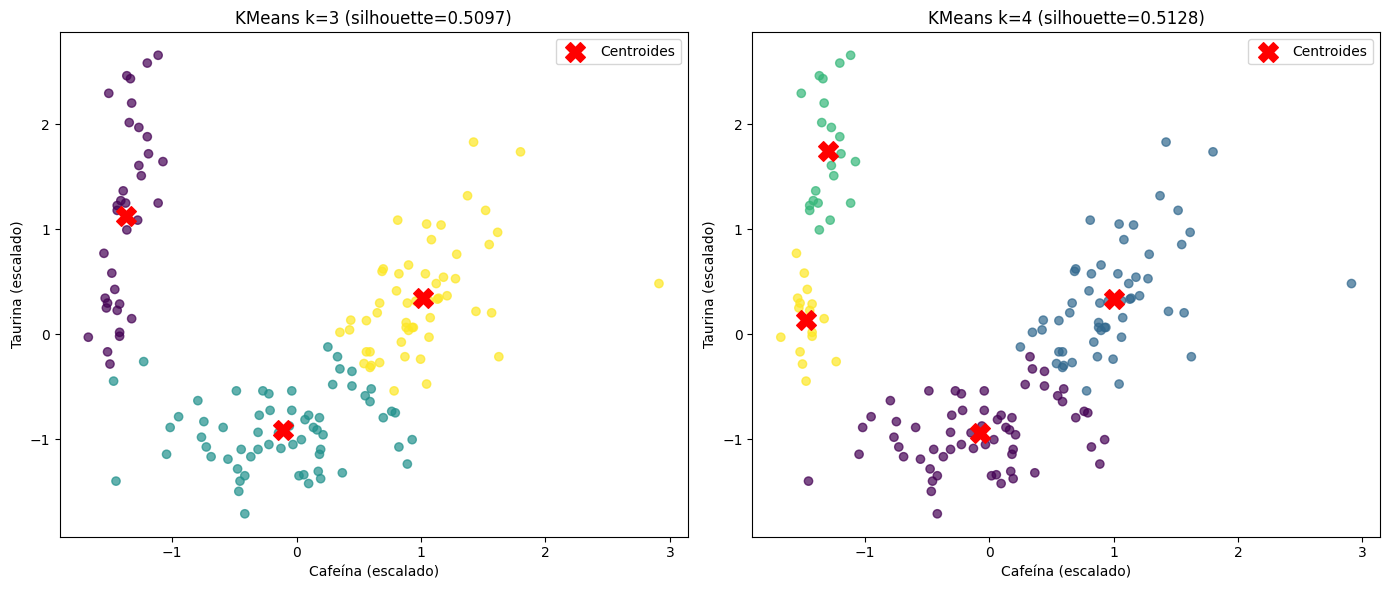

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, k in zip(axes, [3, 4]):
    labels = resultados_kmeans[k]['labels']
    scatter = ax.scatter(X_scaled['Cafeína'], X_scaled['Taurina'], c=labels, cmap='viridis', alpha=0.7)
    centroids = resultados_kmeans[k]['modelo'].cluster_centers_
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroides')
    ax.set_title(f'KMeans k={k} (silhouette={resultados_kmeans[k]["silhouette"]:.4f})')
    ax.set_xlabel('Cafeína (escalado)')
    ax.set_ylabel('Taurina (escalado)')
    ax.legend()

plt.tight_layout()
plt.show()

k = 4 en efecto parece separar mejor los puntos que están más cerca de los ejes de la gráfica, por lo que lo elegimos como la mejor opción para KMeans. Pasamos a DBSCAN.

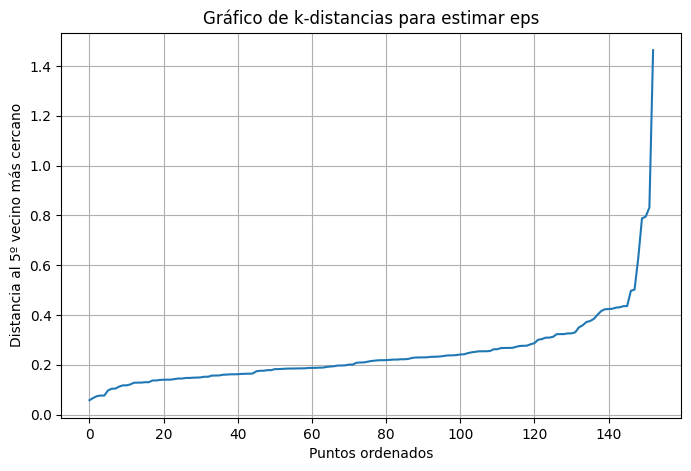

In [17]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 5
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia al {min_samples}º vecino más cercano')
plt.title('Gráfico de k-distancias para estimar eps')
plt.grid(True)
plt.show()

In [18]:
from sklearn.cluster import DBSCAN

eps_elegido = 0.45  
min_samples = 5
dbscan = DBSCAN(eps=eps_elegido, min_samples=min_samples)
labels_dbscan = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_ruido = list(labels_dbscan).count(-1)

print(f"Número de clusters encontrados: {n_clusters_dbscan}")
print(f"Puntos marcados como ruido: {n_ruido}")

if n_clusters_dbscan > 1:
    score_dbscan = silhouette_score(X_scaled, labels_dbscan)
    print(f"Silhouette score: {score_dbscan:.4f}")

Número de clusters encontrados: 2
Puntos marcados como ruido: 4
Silhouette score: 0.4719


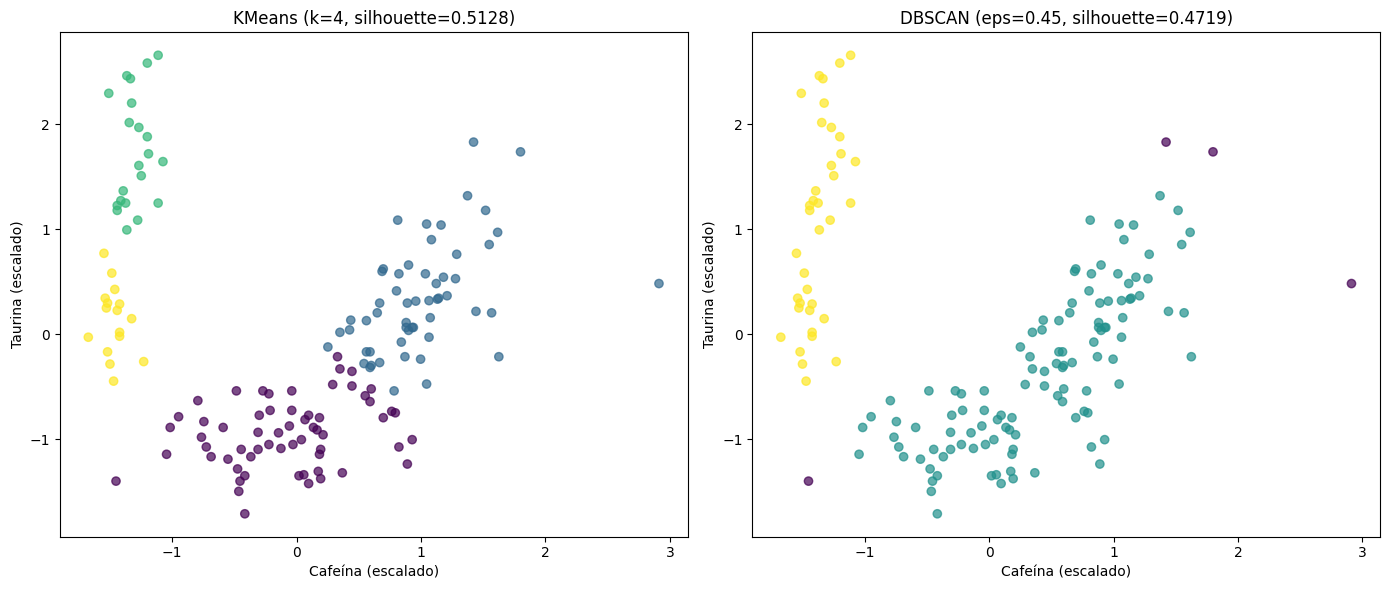

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KMeans
labels_kmeans = resultados_kmeans[4]['labels']
axes[0].scatter(X_scaled['Cafeína'], X_scaled['Taurina'], c=labels_kmeans, cmap='viridis', alpha=0.7)
axes[0].set_title(f'KMeans (k=4, silhouette={resultados_kmeans[4]["silhouette"]:.4f})')
axes[0].set_xlabel('Cafeína (escalado)')
axes[0].set_ylabel('Taurina (escalado)')

# DBSCAN
scatter = axes[1].scatter(X_scaled['Cafeína'], X_scaled['Taurina'], c=labels_dbscan, cmap='viridis', alpha=0.7)
axes[1].set_title(f'DBSCAN (eps=0.45, silhouette={score_dbscan:.4f})')
axes[1].set_xlabel('Cafeína (escalado)')
axes[1].set_ylabel('Taurina (escalado)')

plt.tight_layout()
plt.show()

DBSCAN ve la estructura de datos como más simple que KMeans: en vez de 3-5 grupos diferenciados, según la densidad real de los puntos, hay básicamente 2 grandes zonas densas de combinaciones Cafeína-Taurina. Los puntos que se encuentran entre los 2 clusters encontrados por DBSCAN son los que se tratan como outliers y se colorean de diferente color.

### Parte II. Nuevos experimentos

Los químicos están muy esperanzados con los modelos que les habéis mostrado y os pasan una lista de nuevos experimentos para que los clasifiquéis. Emplea uno de los modelos construidos, el que te resulte más sencillo, para segmentar los nuevos experimentos que puedes encontrar en "./data/new_experiments.csv"

Utilizaremos KMeans para estos datos nuevos.

In [21]:
new_experiments = pd.read_csv('./data/new_experiments.csv', sep="|")
print(new_experiments.shape)
new_experiments.head()

(6, 5)


,Azúcares,Vitamínas del grupo B,Cafeína,Ácido Cítrico,Taurina
0,1.481555,0.305159,1.366128,2.239039,0.731870
1,0.616869,0.890014,0.583034,0.312420,-0.665332
2,-1.680724,0.341713,-0.340615,-0.213021,-0.976782
3,-0.284874,-1.412851,-0.782361,-1.193845,-0.717240
4,-0.927212,0.634140,-1.565455,-0.085641,-0.522583


In [22]:
new_experiments_features = new_experiments[['Cafeína', 'Taurina']]

# Se aplica el mismo scaler ya ajustado con los datos originales (no se reajustan)
new_experiments_scaled = scaler.transform(new_experiments_features)
new_experiments_scaled = pd.DataFrame(new_experiments_scaled, columns=['Cafeína', 'Taurina'])

In [23]:
# Usamos el modelo KMeans ya entrenado (con k=4, el mejor según silhouette)
mejor_modelo_kmeans = resultados_kmeans[4]['modelo']

nuevas_predicciones = mejor_modelo_kmeans.predict(new_experiments_scaled)

new_experiments['cluster_asignado'] = nuevas_predicciones
print(new_experiments)

   Azúcares  Vitamínas del grupo B   Cafeína  Ácido Cítrico   Taurina  \
0  1.481555               0.305159  1.366128       2.239039  0.731870   
1  0.616869               0.890014  0.583034       0.312420 -0.665332   
2 -1.680724               0.341713 -0.340615      -0.213021 -0.976782   
3 -0.284874              -1.412851 -0.782361      -1.193845 -0.717240   
4 -0.927212               0.634140 -1.565455      -0.085641 -0.522583   
5  0.962743              -0.243142 -1.354622      -0.420013  1.956043   

   cluster_asignado  
0                 1  
1                 0  
2                 0  
3                 0  
4                 3  
5                 2  


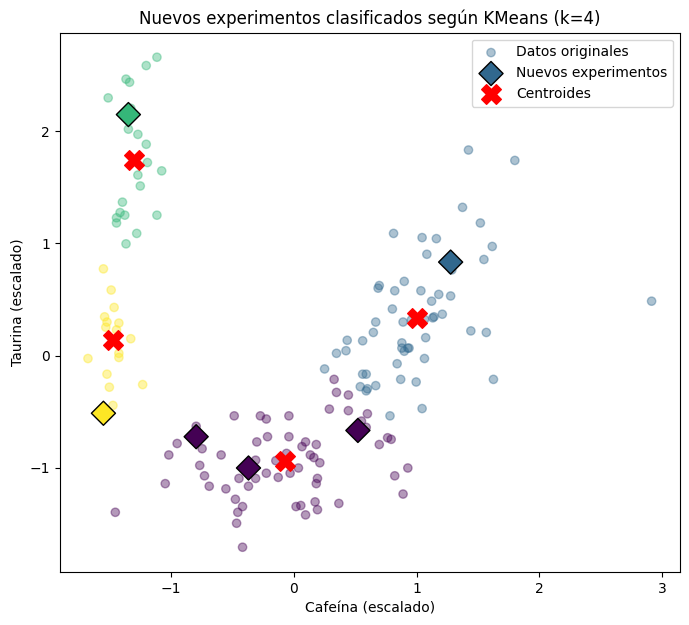

In [25]:
plt.figure(figsize=(8, 7))

# Puntos originales
labels_kmeans_original = resultados_kmeans[4]['labels']
plt.scatter(X_scaled['Cafeína'], X_scaled['Taurina'], c=labels_kmeans_original, cmap='viridis', alpha=0.4, label='Datos originales')

# Nuevos experimentos, marcados de forma distinta
plt.scatter(new_experiments_scaled['Cafeína'], new_experiments_scaled['Taurina'],
            c=nuevas_predicciones, cmap='viridis', edgecolor='black', s=150, marker='D', label='Nuevos experimentos')

# Centroides
centroides = mejor_modelo_kmeans.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1], c='red', marker='X', s=200, label='Centroides')

plt.xlabel('Cafeína (escalado)')
plt.ylabel('Taurina (escalado)')
plt.title('Nuevos experimentos clasificados según KMeans (k=4)')
plt.legend()
plt.show()

Aquí vemos que los nuevos datos desdibujan las fronteras entre los 4 clusters que se habían definido con los datos anteriores. Quizás para esta distribución un algoritmo que entienda este gráfico como densidades de puntos (esdecir, DBSCAN) sea mejor dada la separación en dos regiones claras de los datos. A fin de cuentas, KMeans encontrará tantos centroides como se indiquen para el valor de k.

### Parte III. EXTRA (Voluntario): 6 meses después...

La unidad de experimentación recibió un presupuesto adicional gracias a los modelos que les proporcionastes e hizo pruebas con cliente y obtuvo resultados como para clasificar cada bebida en terminos de "energización" en tres niveles (1, media; 2, media-alta, 3, alta). El resultado de los mismos está en el fichero adecuado en el directorio data y alineado con los experimentos iniciales y al final con los nuevos experimentos de la parte anterior.

Evalua la segmentación de los modelos creados en la primera parte.